In [9]:
import json
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


## Load data files

In [ ]:
all_files = glob.glob("../data/**/*.json", recursive=True)
game_files = [
    f for f in all_files
    if "users" not in f and "sessions" not in f
]

test_files = game_files[:5]
selected_files = test_files

for file_path in selected_files:
    with open(file_path) as file:
        game = json.load(file)
    n_mouse = sum(1 for e in game["events"] if e.get("type") == "MouseEvent")
    print(f"userId={game['userId']}, gameId={game['id']}, mouseEvents={n_mouse}, file={Path(file_path).name}")


all json files:
  userId=42, gameId=33, mouseEvents=6209, file=game-20130219-164243.json
  userId=30, gameId=135, mouseEvents=7544, file=game-20130225-152939.json
  userId=36, gameId=210, mouseEvents=6153, file=game-20130301-161800.json
  userId=5, gameId=359, mouseEvents=4650, file=game-20131207-143426.json
  userId=3, gameId=67, mouseEvents=5332, file=game-20130221-094036.json


## Mouse trajectory preview


userId=42, gameId=33, events=6209

userId=30, gameId=135, events=7544

userId=36, gameId=210, events=6153

userId=5, gameId=359, events=4650

userId=3, gameId=67, events=5332


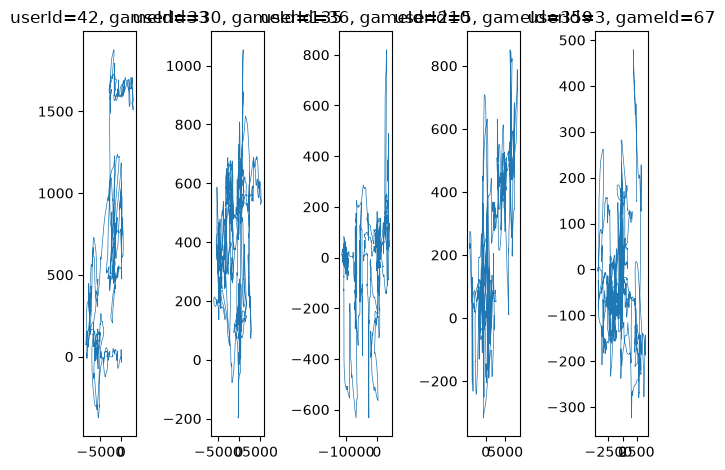

In [21]:
for i, file_path in enumerate(selected_files):
    with open(file_path) as f:
        game_data = json.load(f)

    mouse_events = [
        event for event in game_data["events"]
        if event.get("type") == "MouseEvent"
    ]
    user_id = game_data.get("userId")
    game_id = game_data.get("id")

    df = pd.DataFrame(mouse_events)
    df["trajectory_x"] = df["dx"].cumsum()
    df["trajectory_y"] = df["dy"].cumsum()

    print(f"\nuserId={user_id}, gameId={game_id}, events={len(df)}")
    # print(df[["time", "dx", "dy", "trajectory_x", "trajectory_y"]].head())

    plt.subplot(1, 5, i+1)
    plt.plot(df["trajectory_x"], df["trajectory_y"], linewidth=0.5)
    plt.title(f"userId={user_id}, gameId={game_id}")

plt.tight_layout()
plt.show()

## Feature extraction


In [ ]:
game_rows = []

for file_path in game_files:
    with open(file_path) as file:
        game_data = json.load(file)

    mouse = [e for e in game_data["events"] if e.get("type") == "MouseEvent"]
    if len(mouse) < 2:
        continue

    df = pd.DataFrame(mouse).sort_values("time")

    distance = np.sqrt(df["dx"] ** 2 + df["dy"] ** 2)
    dt = df["time"].diff()
    valid = dt > 0
    speed = distance[valid] / dt[valid]
    angles = np.arctan2(df["dy"], df["dx"]).diff().abs()[valid]

    game_rows.append({
        "userId": game_data["userId"],
        "gameId": game_data["id"],
        "source_file": os.path.basename(file_path),
        "total_movement": distance.sum(),
        "avg_speed": speed.mean(),
        "n_events": len(df),
        "mean_dt": dt[valid].mean(),
        "idle_ratio": (distance < 1).mean(),
        "avg_turn_angle": angles.mean(),
        "speed_std": speed.std(),
        "speed_max": speed.max(),
        "dist_std": distance.std(),
    })

games_df = pd.DataFrame(game_rows)
games_df.to_csv("../data/red_eclipse_features.csv", index=False)
print(games_df.head())


     userId  gameId                source_file  total_movement  avg_speed  \
0        42      33  game-20130219-164243.json   105619.302408   1.256342   
1        30     135  game-20130225-152939.json   111462.797682   0.957887   
2        36     210  game-20130301-161800.json   108200.833182   1.048500   
3         5     359  game-20131207-143426.json    93540.558201   0.958945   
4         3      67  game-20130221-094036.json    91850.417267   0.942099   
..      ...     ...                        ...             ...        ...   
471      41     468  game-20131220-150815.json    77674.613470   0.808971   
472      42      29  game-20130219-162300.json    66615.205644   0.967876   
473      25     263  game-20131204-122003.json   158347.575686   1.296636   
474      13     337  game-20131206-143206.json   140552.339303   1.103295   
475      13     338  game-20131206-143656.json   108736.430882   1.049026   

     n_events    mean_dt  idle_ratio  avg_turn_angle  speed_std  speed_max 

## Player identification


In [52]:
feature_cols = [
    "total_movement", "avg_speed", "n_events", "mean_dt",
    "idle_ratio", "avg_turn_angle", "speed_std", "speed_max", "dist_std",
]

MIN_GAMES = 8
games_df_37 = games_df.groupby("userId").filter(lambda g: len(g) >= MIN_GAMES)

# games_df = 45 players, games_df_37 = more than 8 games
select_model = games_df_37

input_data = select_model[feature_cols]
output_data = select_model["userId"]

input_train, input_test, output_train, output_test = train_test_split(
    input_data, output_data, test_size=0.2, random_state=42, stratify=output_data
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(input_train, output_train)

output_pred = model.predict(input_test)
accuracy = accuracy_score(output_test, output_pred)

print(f"Accuracy: {accuracy:.2%}")
print(f"Random baseline: {1 / output_data.nunique():.2%} ({output_data.nunique()} players, {len(select_model)} games)")
print()
print(classification_report(output_test, output_pred))


Accuracy: 12.50%
Random baseline: 2.70% (37 players, 436 games)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         2
           3       0.12      0.20      0.15         5
           4       1.00      0.33      0.50         3
           5       0.17      0.33      0.22         3
           6       0.17      0.33      0.22         3
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         2
          10       0.17      0.33      0.22         3
          11       0.00      0.00      0.00         2
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00         3
          15       0.00      0.00      0.00         2
          16       0.00      0.00      0.00         3
          19    

/Users/yuc_chang/Documents/bham/cs/project/yxc1228/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/yuc_chang/Documents/bham/cs/project/yxc1228/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/yuc_chang/Documents/bham/cs/project/yxc1228/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to co